In [1]:
%pip install copernicusmarine
%pip install scikit-image


Note: you may need to restart the kernel to use updated packages.


In [2]:
import copernicusmarine
import pandas as pd
import numpy as np
import xarray as xr
from skimage.graph import route_through_array
from matplotlib import pyplot as plt

In [3]:
features = {
    'VHM0': 'sea_surface_wave_significant_height',
    'VTM10': 'sea_surface_wave_mean_period_from_variance_spectral_density_inverse_frequency_moment',
    'VTPK': 'sea_surface_wave_period_at_variance_spectral_density_maximum',
    'VMDR': 'sea_surface_wave_from_direction',
    'VHM0_WW': 'sea_surface_wind_wave_significant_height',
    'VMDR_WW': 'sea_surface_wind_wave_from_direction',
    'VHM0_SW1': 'sea_surface_primary_swell_wave_significant_height',
    'VTM01_SW1': 'sea_surface_primary_swell_wave_mean_period'
}

In [4]:
dataset = copernicusmarine.open_dataset(
  dataset_id="cmems_mod_glo_wav_anfc_0.083deg_PT3H-i",
  variables = [x for x in features],
  minimum_longitude=-180,
  maximum_longitude=179.91666666666666,
  minimum_latitude=-80,
  maximum_latitude=90,
  start_datetime="2024-09-05T00:00:00",
  end_datetime="2024-09-05T00:00:00",
)

INFO - 2024-09-05T16:50:18Z - Dataset version was not specified, the latest one was selected: "202311"
INFO - 2024-09-05T16:50:18Z - Dataset part was not specified, the first one was selected: "default"
INFO - 2024-09-05T16:50:23Z - Service was not specified, the default one was selected: "arco-geo-series"


username:

  praam


password:

  ········


In [5]:
dataset

<xarray.Dataset> Size: 564MB
Dimensions:    (time: 1, latitude: 2041, longitude: 4320)
Coordinates:
  * latitude   (latitude) float64 16kB -80.0 -79.92 -79.83 ... 89.83 89.92 90.0
  * longitude  (longitude) float64 35kB -180.0 -179.9 -179.8 ... 179.8 179.9
  * time       (time) datetime64[ns] 8B 2024-09-05
Data variables:
    VHM0       (time, latitude, longitude) float64 71MB ...
    VTM10      (time, latitude, longitude) float64 71MB ...
    VTPK       (time, latitude, longitude) float64 71MB ...
    VMDR       (time, latitude, longitude) float64 71MB ...
    VHM0_WW    (time, latitude, longitude) float64 71MB ...
    VMDR_WW    (time, latitude, longitude) float64 71MB ...
    VHM0_SW1   (time, latitude, longitude) float64 71MB ...
    VTM01_SW1  (time, latitude, longitude) float64 71MB ...
Attributes: (12/16)
    Conventions:           CF-1.6
    area:                  GLO
    contact:               servicedesk.cmems@mercator-ocean.eu
    credit:                E.U. Copernicus Marine Service Information (CMEMS)
    geospatial_lat_max:    90.0
    geospatial_lat_min:    -80.0
    ...                    ...
    geospatial_lon_step:   0.0833282470703125
    geospatial_lon_units:  degree
    institution:           METEO-FRANCE
    producer:              CMEMS - Global Monitoring and Forecasting Centre
    product:               GLOBAL_ANALYSIS_FORECAST_WAV_001_027
    references:            http://marine.copernicus.eu

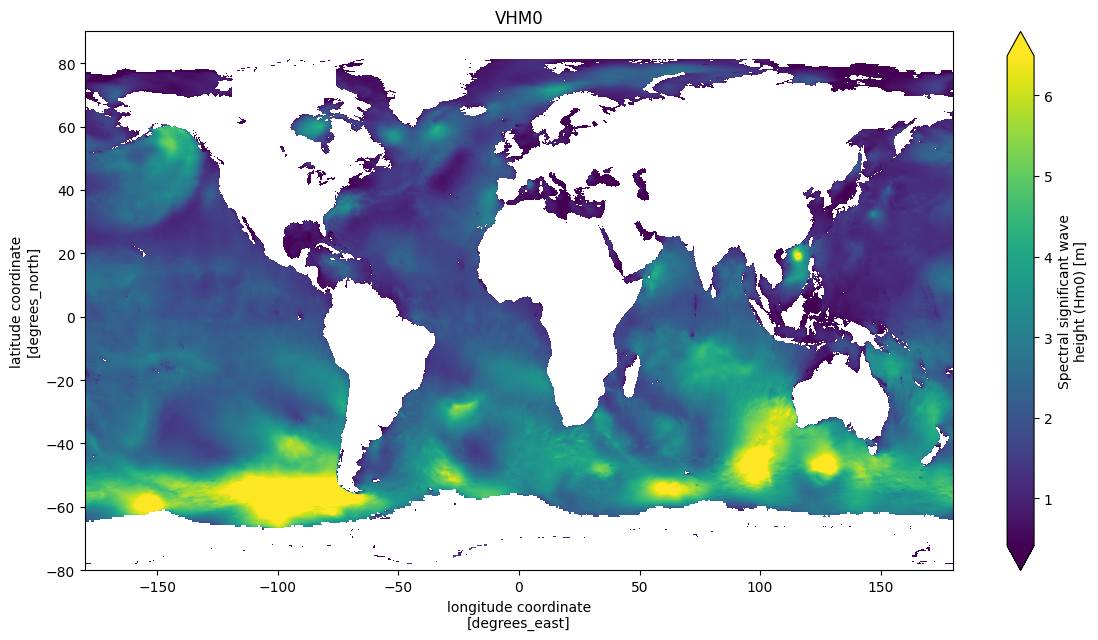

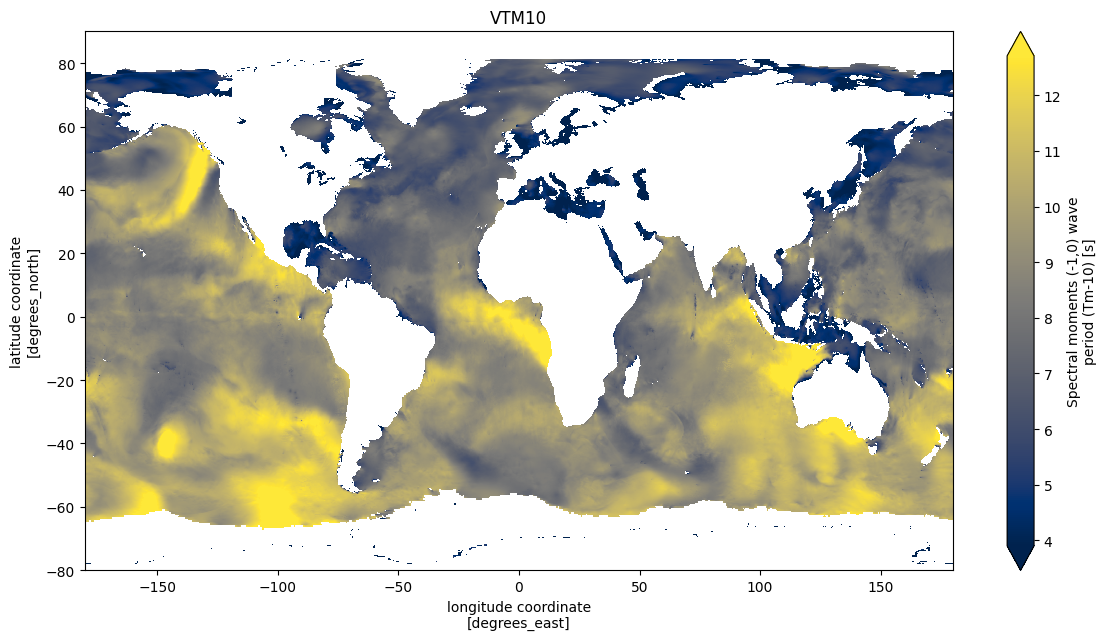

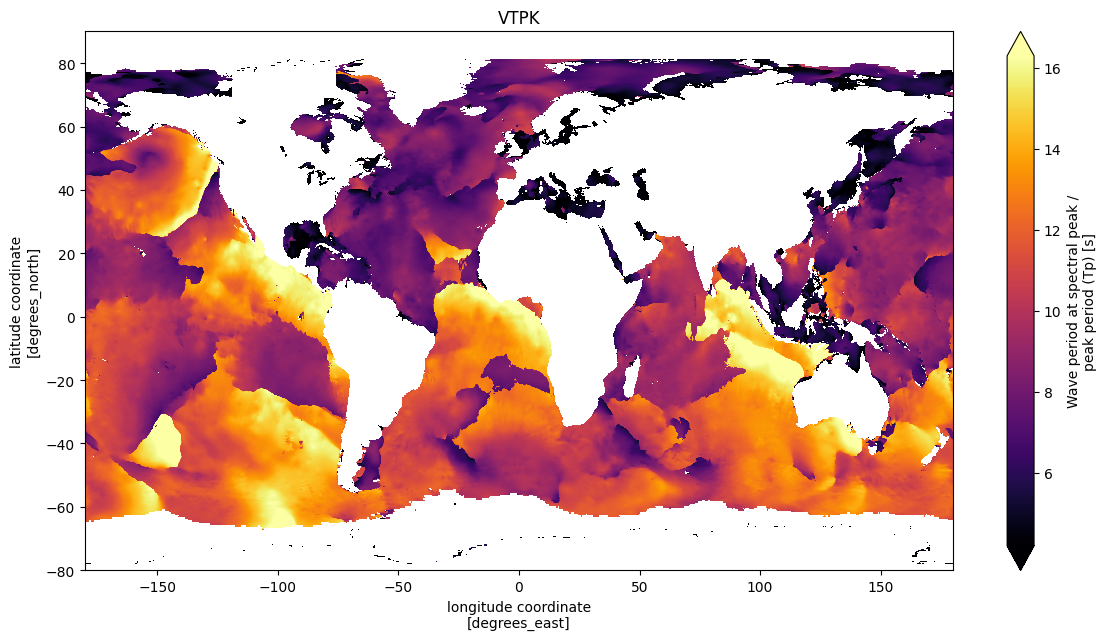

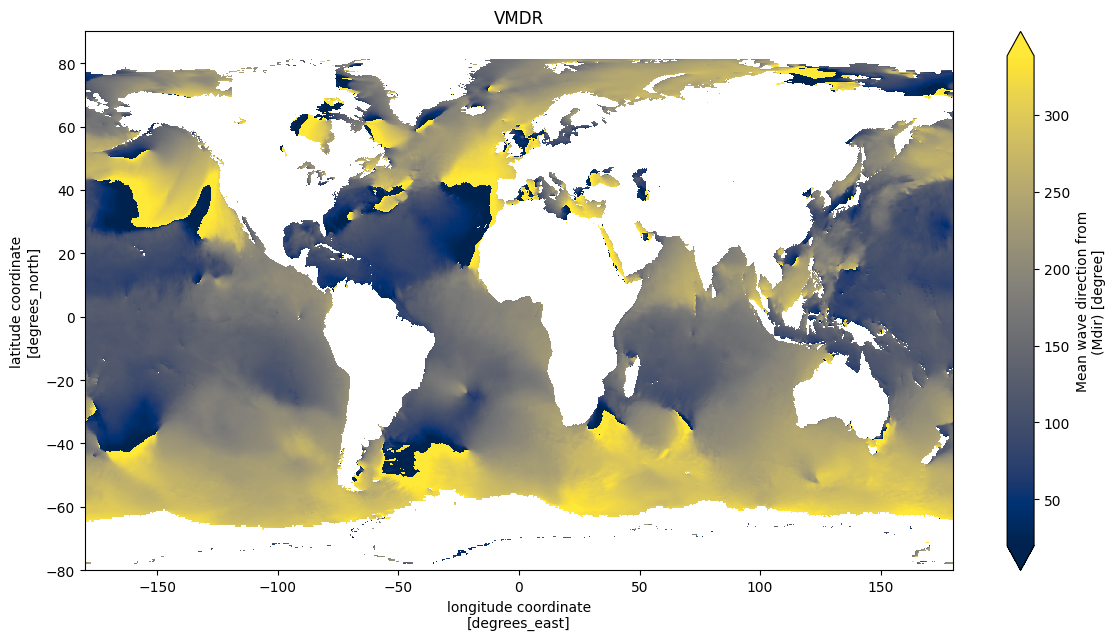

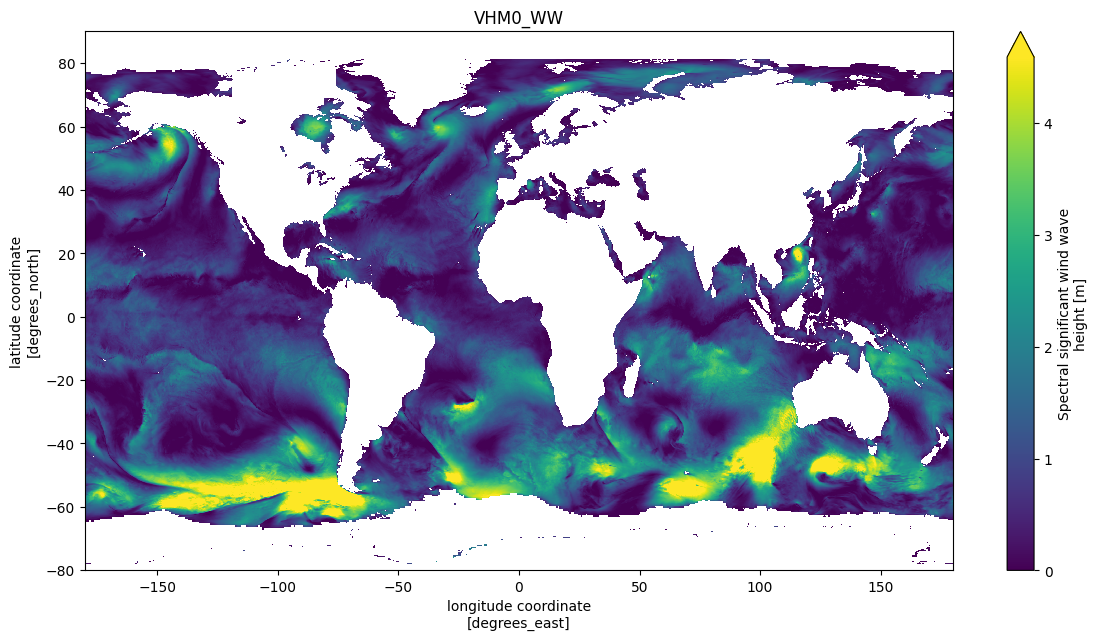

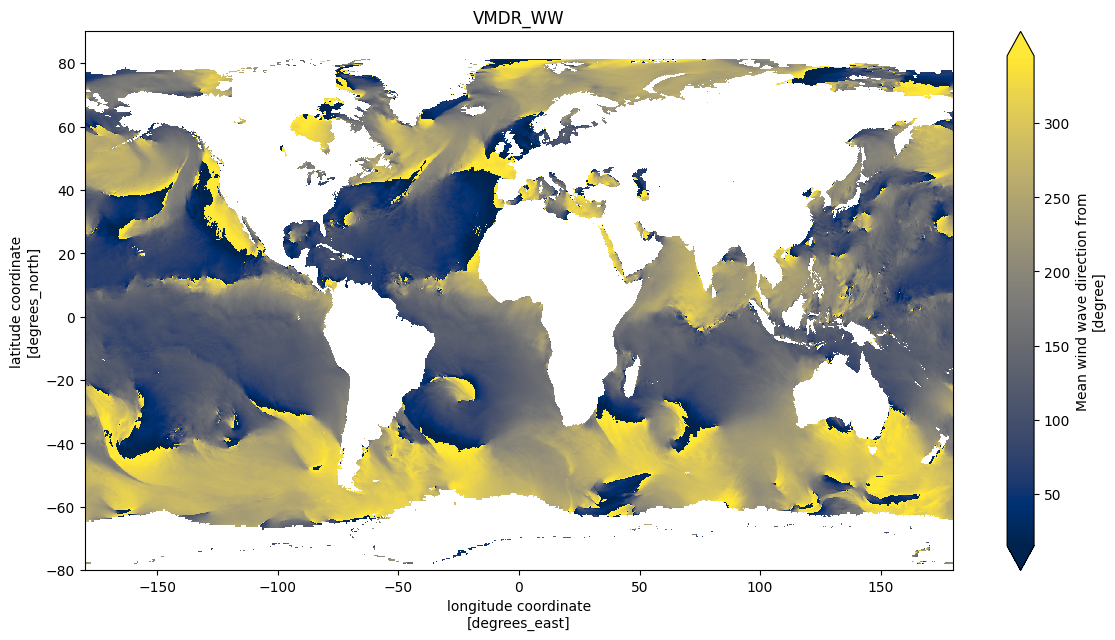

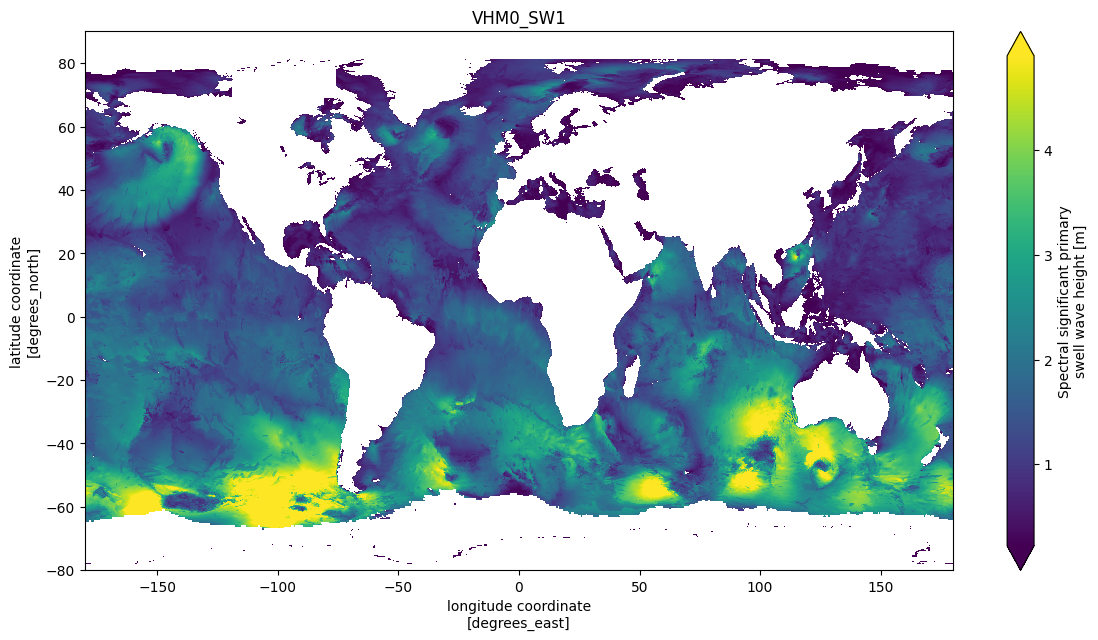

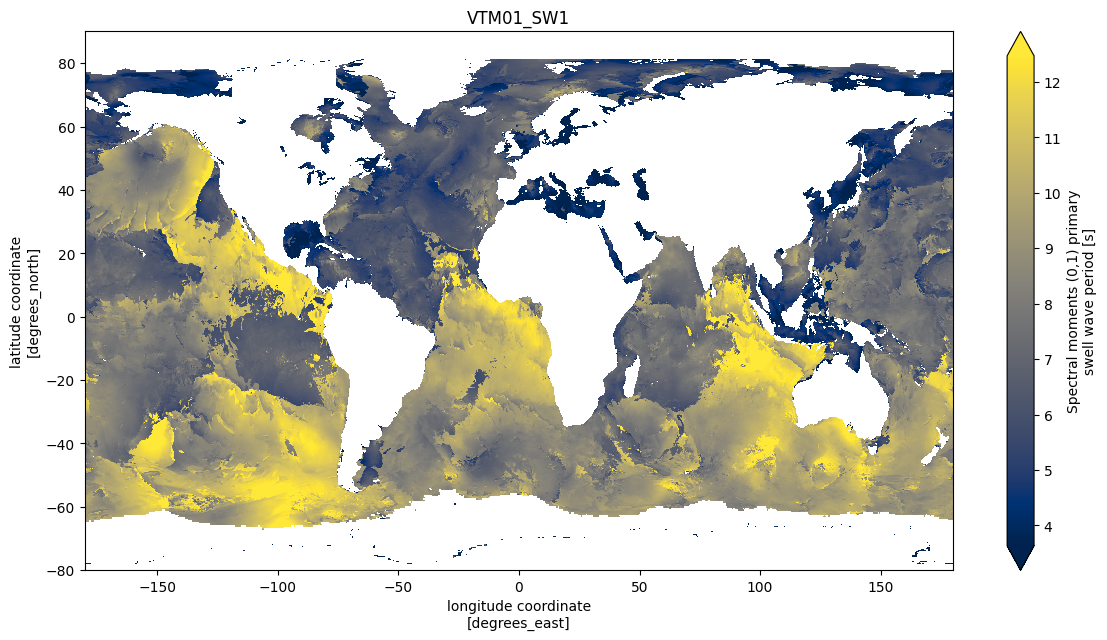

In [6]:
cmap_dict = {
    'VHM0': 'viridis',
    'VTM10': 'cividis',
    'VTPK': 'inferno',
    'VMDR': 'cividis',
    'VHM0_WW': 'viridis',
    'VMDR_WW': 'cividis',
    'VHM0_SW1': 'viridis',
    'VTM01_SW1': 'cividis'
}

for feature in features:
    if hasattr(dataset, feature):
        cmap = cmap_dict.get(feature, 'viridis')  # Default to 'viridis' if not found
        dataset[feature].isel(time=0).plot(robust=True, aspect=2, size=7, cmap=cmap)
        plt.title(feature)
        plt.show()
    else:
        print(f"Feature {feature} not found in dataset.")

In [7]:
df = dataset.to_dataframe()

In [8]:
df

VHM0  VTM10  VTPK  VMDR  VHM0_WW  VMDR_WW  \
time       latitude longitude                                                
2024-09-05 -80.0    -180.000000   NaN    NaN   NaN   NaN      NaN      NaN   
                    -179.916667   NaN    NaN   NaN   NaN      NaN      NaN   
                    -179.833333   NaN    NaN   NaN   NaN      NaN      NaN   
                    -179.750000   NaN    NaN   NaN   NaN      NaN      NaN   
                    -179.666667   NaN    NaN   NaN   NaN      NaN      NaN   
...                               ...    ...   ...   ...      ...      ...   
            90.0     179.583333   NaN    NaN   NaN   NaN      NaN      NaN   
                     179.666667   NaN    NaN   NaN   NaN      NaN      NaN   
                     179.750000   NaN    NaN   NaN   NaN      NaN      NaN   
                     179.833333   NaN    NaN   NaN   NaN      NaN      NaN   
                     179.916667   NaN    NaN   NaN   NaN      NaN      NaN   

                                 VHM0_SW1  VTM01_SW1  
time       latitude longitude                         
2024-09-05 -80.0    -180.000000       NaN        NaN  
                    -179.916667       NaN        NaN  
                    -179.833333       NaN        NaN  
                    -179.750000       NaN        NaN  
                    -179.666667       NaN        NaN  
...                                   ...        ...  
            90.0     179.583333       NaN        NaN  
                     179.666667       NaN        NaN  
                     179.750000       NaN        NaN  
                     179.833333       NaN        NaN  
                     179.916667       NaN        NaN  

[8817120 rows x 8 columns]

In [9]:
lat_NY = 40.7128
lon_NY = -74.0060
lat_LS = 38.7223
lon_LS = -9.1393

In [10]:
# Get array index to the value that is closest to a given value
def get_closest(array, value):
    return np.abs(array - value).argmin()

In [11]:
start_lon = get_closest(dataset.longitude.data, lon_NY)
start_lat = get_closest(dataset.latitude.data, lat_NY)
end_lon = get_closest(dataset.longitude.data,lon_LS)
end_lat = get_closest(dataset.latitude.data,lat_LS)

In [12]:
start = (start_lat, start_lon)
end = (end_lat, end_lon)

In [13]:
feature_costs = {}
feature_nans = {}

for feature in features:
    if hasattr(dataset, feature):
        # Store the cost data for each feature in the dictionary
        costs = dataset[feature].data[0]
        feature_costs[f"{feature}_costs"] = costs
        
        # Check where NaN values are present in the cost data and store in feature_nans
        whereAreNans = np.isnan(costs)
        feature_nans[f"{feature}_nans"] = whereAreNans

    else:
        print(f"Feature {feature} not found in dataset.")

In [14]:
feature_costs

{'VHM0_costs': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 'VTM10_costs': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 'VTPK_costs': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 'VMDR_costs': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]

In [15]:
feature_nans

{'VHM0_nans': array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]]),
 'VTM10_nans': array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]]),
 'VTPK_nans': array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
     

In [16]:
for feature in features:
    if hasattr(dataset, feature):
        
        # Retrieve the stored cost data and NaN positions
        costs = feature_costs[f"{feature}_costs"]
        whereAreNans = feature_nans[f"{feature}_nans"]
        
        # Update the cost data where NaNs were found
        costs[whereAreNans] = 10**9
        
        # Store the updated costs back into feature_costs
        feature_costs[f"{feature}_costs"] = costs
    else:
        print(f"Feature {feature} not found in dataset.")

In [17]:
feature_costs

{'VHM0_costs': array([[1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        ...,
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09]]),
 'VTM10_costs': array([[1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        ...,
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09]]),
 'VTPK_costs': array([[1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09, 1.e+09, 1.e+09],
        [1.e+09, 1.e+09, 1.e+09, ..., 1.e+09,

In [18]:
feature_weights = {
    'VHM0': 0.25,
    'VTM10': 0.15,
    'VTPK': 0.20,
    'VMDR': 0.10,
    'VHM0_WW': 0.20,
    'VMDR_WW': 0.05,
    'VHM0_SW1': 0.10,
    'VTM01_SW1': 0.05
}

In [19]:
# Calculate the final cost array
final_cost = np.zeros_like(next(iter(feature_costs.values())))  # Initialize with the shape of any feature data
for feature in features:
    final_cost += feature_costs[f'{feature}_costs'] * feature_weights[feature]

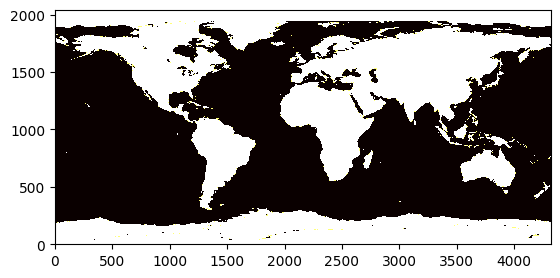

In [20]:
plt.imshow(final_cost, cmap="hot", interpolation="nearest")
plt.gca().invert_yaxis();

In [21]:
def pathfinding(start, end):
    return route_through_array(final_cost, start, end, fully_connected=True)

In [22]:
indices, weight = pathfinding(start, end)
indices = np.stack(indices, axis=-1)

In [23]:
indices

array([[1449, 1448, 1447, ..., 1424, 1424, 1425],
       [1272, 1272, 1272, ..., 2048, 2049, 2050]])

In [24]:
weight

2427828303.168956

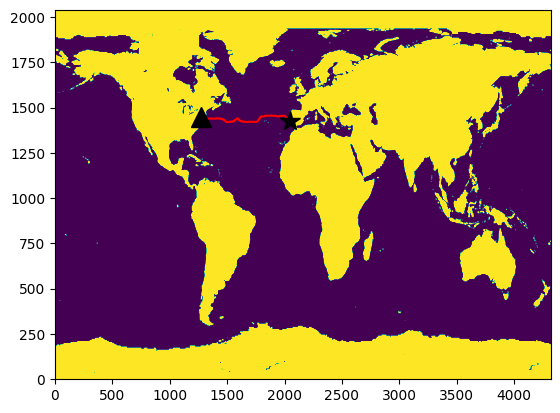

In [25]:
# Plot optimal route

plt.imshow(final_cost, aspect='auto', vmin=np.min(final_cost), vmax=0.5*np.max(final_cost));
# Route
plt.plot(indices[1],indices[0], 'r')
# Start/end points
plt.plot(start_lon, start_lat, 'k^', markersize=15)
plt.plot(end_lon, end_lat, 'k*', markersize=15)
plt.gca().invert_yaxis();